<h1 style="text-align: center;">Modelos de ensamble, SVM y redes neuronales</h1>

## Descripción del problema
En este trabajo, se maneja un problema de clasificación a partir de la identificación de la especia de una planta con ayuda de sus características físicas. En este caso, se conocen algunas medidas de la planta y se busca asignar la especie de planta a una de las categorías. En esta actividad se utiliza el conjunto de datos Iris, obtenidos del UCI Machine Learning Repository, y se cuentan con 150 plantas de tres especies: Iris setosa, Iris versicolor e Iris virginica. De cada planta se registra el largo del sépalo, el ancho del sépalo, el largo del pétalo y el ancho del pétalo.

El objetivo de este trabajo es desarrollar modelos que utilicen estas cuatro medidas para predecir la especie de plantas que no hayan visto durante el conjunto de entrenamiento. Para realizar esto, se comparan Random Forest, Boosting, SVM y una red neuronal simple, utilizando la partición de datos en entrenamiento y prueba para evaluar su desempeño de manera consistente. Esta comparación entre los distintos métodos permitirá observar qué tan bien distingue cada modelo las tres especies y si una mayor complejidad produce una mejora en los resultados.

En la Tabla 1, se puede observar una vista previa del conjunto de datos disponibles en la base de datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

Pandas: 2.2.3
Scikit-learn: 1.6.1
TensorFlow: 2.20.0


In [3]:
data = pd.read_csv(
    "/iris.csv",
    header=None,
    names=["Largo del sépalo", "Ancho del sépalo",
           "Largo del pétalo", "Ancho del pétalo", "Especie"]
)

data.head(10).style.hide(axis="index").set_properties(
    **{"text-align": "center"}
).set_table_styles([
    {"selector": "th", "props": [("text-align", "center")]}
]).set_caption("[TABLA 1]. Vista previa del conjunto de datos.")

Largo del sépalo,Ancho del sépalo,Largo del pétalo,Ancho del pétalo,Especie
5.100000,3.500000,1.400000,0.200000,Iris-setosa
4.900000,3.000000,1.400000,0.200000,Iris-setosa
4.700000,3.200000,1.300000,0.200000,Iris-setosa
4.600000,3.100000,1.500000,0.200000,Iris-setosa
5.000000,3.600000,1.400000,0.200000,Iris-setosa
5.400000,3.900000,1.700000,0.400000,Iris-setosa
4.600000,3.400000,1.400000,0.300000,Iris-setosa
5.000000,3.400000,1.500000,0.200000,Iris-setosa
4.400000,2.900000,1.400000,0.200000,Iris-setosa
4.900000,3.100000,1.500000,0.100000,Iris-setosa


## Distribución de las clases
La base de datos cuenta con 150 observaciones, de las cuales 50 pertenecen a Iris setosa, 50 a Iris versicolor y 50 a Iris virginica. Como se observa en la Gráfica 1, cada especie tiene 50 registros, por lo que las clases se encuentran equilibradas. Esto permite comparar el desempeño de los modelos sin que una clase tenga una mayor importancia que la otra.

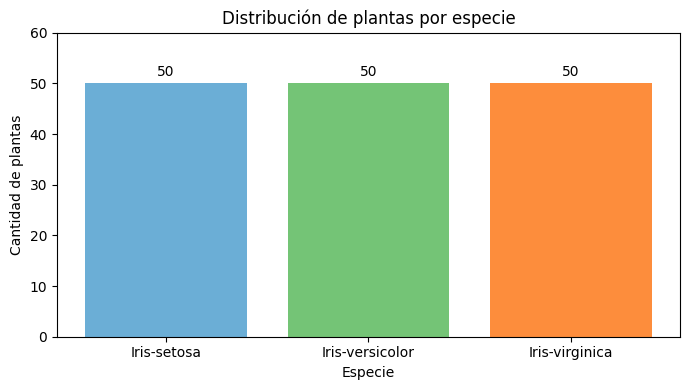

In [4]:
conteo = data["Especie"].value_counts()

plt.figure(figsize=(7, 4))
barras = plt.bar(conteo.index, conteo.values, color=["#6baed6", "#74c476", "#fd8d3c"])

plt.bar_label(barras, padding=3)
plt.title("Distribución de plantas por especie")
plt.xlabel("Especie")
plt.ylabel("Cantidad de plantas")
plt.ylim(0, conteo.max() + 10)
plt.tight_layout()
plt.show()

[GRÁFICA 1]. Distribución de plantas por especie.

## División de datos en entrenamiento y prueba
El conjunto de datos se dividió en dos partes, con el 70% en entrenamiento y el restante 30% a prueba. Esto corresponde a 105 plantas de entrenamiento y 45 plantas de prueba.

La división se hizo de forma estratificada, por lo que se conservó la proporción de las tres especies en ambos conjuntos, es decir, 35 plantas de cada especie en entrenamiento y 15 plantas de cada especie en prueba. Se utilizó la misma partición para Random Forest, Boosting, SVM y la red neuronal simple, de tal modo que sus resultados se puedan comparar utilizando las mismas condiciones.

In [5]:
from sklearn.model_selection import train_test_split

X = data.drop(columns="Especie")
y = data["Especie"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=27
)

tabla_particion = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Cantidad de plantas": [len(X_train), len(X_test)]
})

display(tabla_particion.style.hide(axis="index").set_caption(
    "[TABLA 2]. División del conjunto de datos."
))

Conjunto,Cantidad de plantas
Entrenamiento,105
Prueba,45


## Random Forest

### Entrenamiento del modelo
El primer modelo entrenado fue Random Forest, un método que combina las predicciones de varios árboles de decisión para clasificar a cada planta. Se utilizaron las 105 plantas del conjunto de entrenamiento y sus cuatro variables.

El modelo se configuró con 100 árboles y una profundidad máxima de 4 niveles. Esta configuración permite que los árboles identifiquen relaciones entre las medidas y as especies, mientras limita el tamaño de cada uno.

Una vez que el modelo fue entrenado, quedó listo para predecir las especies de las 45 plantas reservadas para la prueba.

In [6]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=27
)

modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")
print(f"Plantas utilizadas para entrenar: {len(X_train)}")
print(f"Cantidad de árboles: {modelo_rf.n_estimators}")

Modelo Random Forest entrenado correctamente.
Plantas utilizadas para entrenar: 105
Cantidad de árboles: 100


### Evaluación del modelo
El modelo de Random Forest clasificó correctamente a 42 de las 45 plantas del conjunto de prueba, con un nivel de accuracy de 93.3%. Identificó correctamente a las 15 plantas Iris setosa y las 15 Iris versicolor. De las 15 plantas Iris virginica, clasificó correctamente 12 y se observó que confundió las 3 restantes con Iris versicolor.

La Gráfica 2 muestra la matriz de confusión de este modelo. Esta matriz de confusión enseña que los errores se concentraron en la distinción entre Iris virginica e Iris versicolor, como ya se había mencionado anteriormente. Para Iris virginica, el recall fue de 0.80, lo que significa que el modelo reconoció el 80% de las plantas de esa especie. En cambio, Iris setosa obtuvo precisión y recall de 1.00, o 100%, en el conjunto de prueba. En general, el modelo tuvo un buen desempeño a pesar de las dificultades presentadas.

Accuracy en prueba: 0.933

Reporte de clasificación:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.83      1.00      0.91        15
 Iris-virginica       1.00      0.80      0.89        15

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.94      0.93      0.93        45



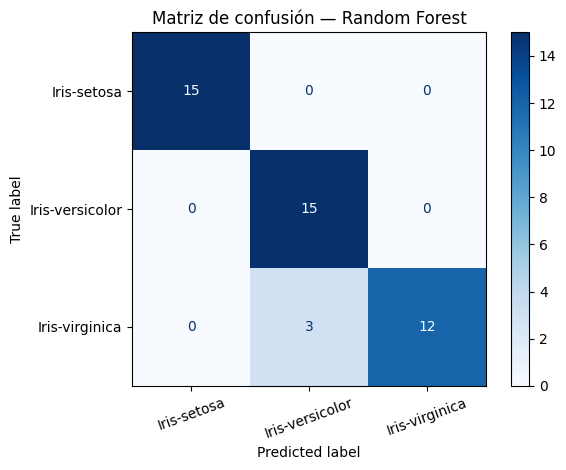

In [7]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred_rf = modelo_rf.predict(X_test)

print(f"Accuracy en prueba: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=modelo_rf.classes_,
    cmap="Blues",
    xticks_rotation=20
)

plt.title("Matriz de confusión — Random Forest")
plt.tight_layout()
plt.show()

[GRÁFICA 2]. Matriz de confusión del modelo de Random Forest.

### Importancia de las variables
La Gráfica 3 muestra que Random Forest se apoyó principalmente en las medidas del pétalo para clasificar las plantas. El largo del pétalo obtuvo la mayor importancia, con un valor de 0.469, seguido del ancho del pétalo, con un valor de 0.407. Estas dos variables juntas representan alrededor del 87.6% de la importancia calculada por el medalo.

Las medidas del sépalo tuvieron valores menores, con 0.102 para el largo y 0.022 para el ancho. Lo que demuestta que, en este modelo, las medidas del pétalo fueron más útiles para separar las tres especies. Estos valores describen cuánto contribuyó cada variable a las divisiones de los árboles.

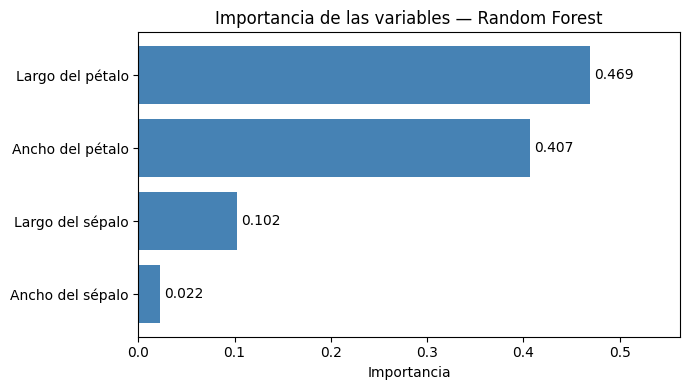

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(7, 4))
barras = plt.barh(importancias.index, importancias.values, color="steelblue")

plt.bar_label(barras, fmt="%.3f", padding=3)
plt.xlabel("Importancia")
plt.title("Importancia de las variables — Random Forest")
plt.xlim(0, importancias.max() * 1.2)
plt.tight_layout()
plt.show()

[GRÁFICA 3]. Importancia de las variables en el modelo de Random Forest.

### Curva ROC
La Gráfica 4 contiene a la Curva ROC, la cual muestra qué tan bien distingue Random Forest a cada especie frente a las otras dos cuando se cambia el umbral de clasificación. Las tres curvas se mantienen cerca de la esquina superior izquierda. LAs tres clases presentan un AUC de 1.0, lo que muestra que el modelo ordenó muy bien las plantas según la probabilidad asignada a cada especie.

Sin embargo, es importante recalcar que este resultado no significa que todas las predicciones hayan sido correctas.

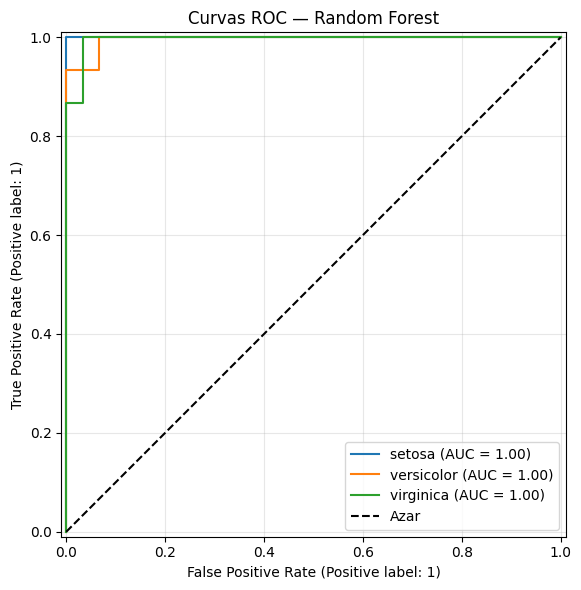

In [9]:
from sklearn.metrics import RocCurveDisplay

probabilidades_rf = modelo_rf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 6))

for i, especie in enumerate(modelo_rf.classes_):
    es_especie = (y_test == especie).astype(int)

    RocCurveDisplay.from_predictions(
        es_especie,
        probabilidades_rf[:, i],
        name=especie.replace("Iris-", ""),
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title("Curvas ROC — Random Forest")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

[GRÁFICA 4]. Curva ROC del modelo de Random Forest.

## Boosting

### Entrenamiento del modelo
El segundo modelo entrenado fue Boosting. Este método construye árboles de decisión de forma secuencial, es decir, cada nuevo árbol busca mejorar la clasificación obtenida con los anteriores. Para entrenarlo se utilizaron las mismas plantas y las mismas cuatro variables empleadas anteriormente, permitiendo la comparación de los resultados de los modelos.

Se configuraron 100 árboles con una profundidad máxima de dos niveles y un Learning Rate de 0.05.

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

modelo_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=27
)

modelo_boosting.fit(X_train, y_train)

print("Modelo Boosting entrenado correctamente.")
print(f"Plantas utilizadas para entrenar: {len(X_train)}")
print(f"Cantidad de árboles: {modelo_boosting.n_estimators}")

Modelo Boosting entrenado correctamente.
Plantas utilizadas para entrenar: 105
Cantidad de árboles: 100


### Evaluación del modelo
Después del entrenamiento, el modelo Boosting se evaluó con el conjunto de prueba. Oara analizar su desempeño, se calculó la exactitud, precisión, el recall y el F1-Score de cada especie. Este modelo clasificó correctamente 43 de las 45 plantas de prueba, con una exactitud de 95.6%. Según la Gráfica 5, el modelo identificó sin errores las 15 plantas de Iris seotsa y las 15 plantas Iris virginica. Sin embargo, de las 15 plantas Iris virginica, reconoció correctamente 13 y clasificó dos como Iris versicolor.

La mayor dificultad estuvo en distinguir las planas Iris virginica de Iris versicolor. Para Iris virginica, el recall fue de 0.87, mientras que para las otras dos especies fue de 1.00.

Accuracy en prueba: 0.956

Reporte de clasificación:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



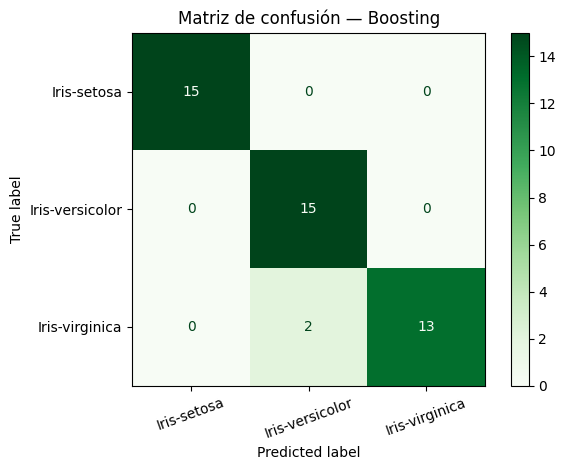

In [11]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred_boosting = modelo_boosting.predict(X_test)

print(f"Accuracy en prueba: {accuracy_score(y_test, y_pred_boosting):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_boosting))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_boosting,
    labels=modelo_boosting.classes_,
    cmap="Greens",
    xticks_rotation=20
)

plt.title("Matriz de confusión — Boosting")
plt.tight_layout()
plt.show()

[GRÁFICA 5]. Matriz de confusión del modelo de Boosting.

### Curva ROC
Las curvas ROC de Boosting se encuentran cerca de la esquina superior izquierda. El AUC mostrado es de 1.00 para las tres especies de plantas, lo que indica que el modelo distingue muy bien cada especie de las otras al variar el umbral de clasificación.

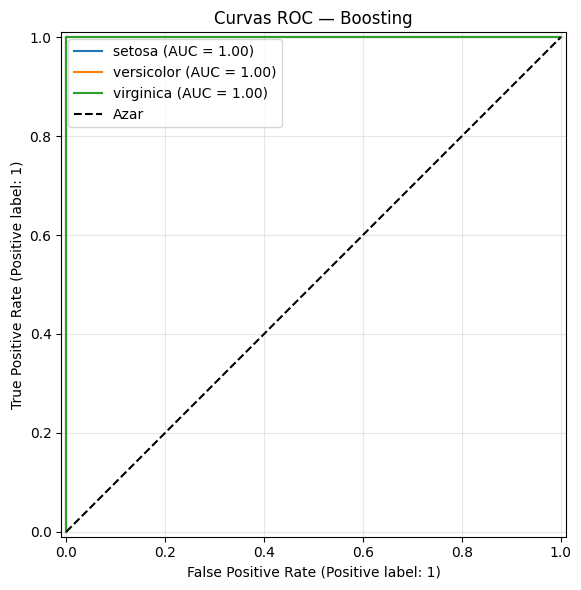

In [12]:
from sklearn.metrics import RocCurveDisplay

probabilidades_boosting = modelo_boosting.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 6))

for i, especie in enumerate(modelo_boosting.classes_):
    es_especie = (y_test == especie).astype(int)

    RocCurveDisplay.from_predictions(
        es_especie,
        probabilidades_boosting[:, i],
        name=especie.replace("Iris-", ""),
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title("Curvas ROC — Boosting")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

[GRÁFICA 6]. Curva ROC del modelo de Boosting.

## SVM

### Entrenamiento del modelo
Para continuar con el problema de clasificación, ahora se entrenó un modelo de Support Vector Machines (o SVM) con las cuatro medidas disponibles en la base de datos. Antes del entrenamiento, las variables se estandarizaron para que sus diferencias de escala no influyeran en el modelo. Se utilizó un núcleo RBF, que permite establecer límites de separación no lineales entre las especies.

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

modelo_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=27
    )
)

modelo_svm.fit(X_train, y_train)

print("Modelo SVM entrenado correctamente.")
print(f"Plantas utilizadas para entrenar: {len(X_train)}")
print("Kernel utilizado: RBF")

Modelo SVM entrenado correctamente.
Plantas utilizadas para entrenar: 105
Kernel utilizado: RBF


### Evaluación del modelo
El modelo SVM obtuvo una exactitud de 95.6% en el conjunto de prueba, es decir, se clasificaron correctamente a 43 de las 45 plantas. El F1 promedio fue de 0.96, lo que indica un buen desempeño de las tres especies.

La Gráfica 7 muestra que la matriz de confusión permite ver cuáles plantas se clasificaron correctamente y en cuáles se equivocó. Se identificaron a las 15 plantas Iris setosa, las 15 Iris versicolor, pero de las 15 Iris virginica se clasificaron correctamente 13 y se confundieron 2 con Iris versicolor. La matriz muestra 43 aciertos y 2 errores, por lo que la dificultad principal del modelo está en distinguir entre Iris virginica e Iris versicolor.

Accuracy en prueba: 0.956

Reporte de clasificación:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



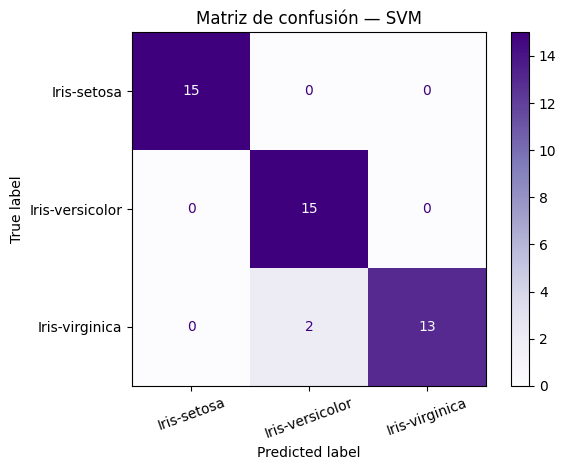

In [14]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred_svm = modelo_svm.predict(X_test)

print(f"Accuracy en prueba: {accuracy_score(y_test, y_pred_svm):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    labels=modelo_svm.classes_,
    cmap="Purples",
    xticks_rotation=20
)

plt.title("Matriz de confusión — SVM")
plt.tight_layout()
plt.show()

[GRÁFICA 7]. Matriz de confusión del modelo SVM.

### Curva ROC
Las curvas ROC del modelo muestran cómo distingue el modelo cada especie en comparación con las otras dos. En la gráfica, las tres curvas se mantienen cerca de la esquina superior izquierda y muestran un AUC de 1.00 para cada una de las especies. Esto indica que el modelo ordenó bien las plantas según la probabilidad asignada a cada especie.

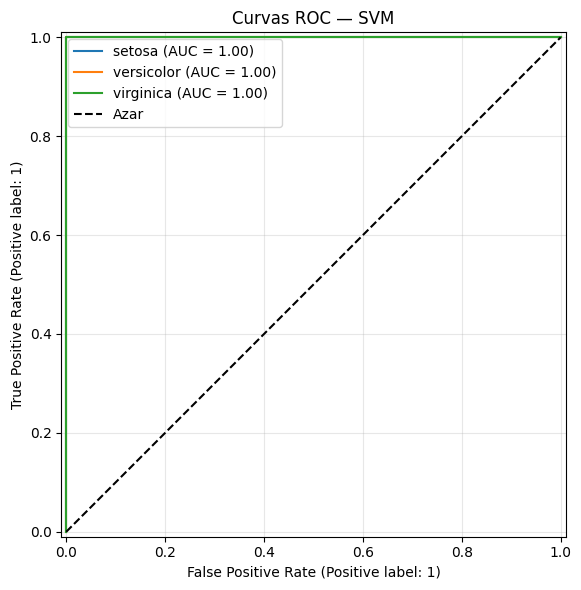

In [15]:
from sklearn.metrics import RocCurveDisplay

probabilidades_svm = modelo_svm.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 6))

for i, especie in enumerate(modelo_svm.classes_):
    es_especie = (y_test == especie).astype(int)

    RocCurveDisplay.from_predictions(
        es_especie,
        probabilidades_svm[:, i],
        name=especie.replace("Iris-", ""),
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title("Curvas ROC — SVM")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

[GRÁFICA 8]. Curvas ROC del modelo SVM.

## Red Neuronal

### Entrenamiento del modelo
Ahora, se entrenó una red neuronal sencilla para clasificar las plantas en las tres especies utilizando las variables que ya se han estado trabajando. Antes del entrenamiento del modelo, las medidas se estandarizaron. El modelo se configuró con una capa oculta de 8 neurones y una capa de salida que calcula la probabilidad de pertenecer a cada especie.

Para el entrenamiento se utilizaron 73 plantas y se reservaron otras 32 para la validación. Se estableció un máximo de 300 épocas, durante las cuales la red neuronal ajusta sus conexiones para hacer mejores predicciones en el modelo. Asimismo, se utilizó una parada temprana para detener el entrenamiento si la pérdida de validación deja de mejorar y así el modelo pueda conservar los mejores pesos del modelo. Las 45 plantas de prueba se reservaron para la evaluación posterior.

In [16]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical

tf.keras.utils.set_random_seed(27)

# Convertir las especies a números
codificador_rn = LabelEncoder()
y_train_num = codificador_rn.fit_transform(y_train)
n_clases = len(codificador_rn.classes_)

# Reservar parte del entrenamiento para validación
X_ent, X_val, y_ent, y_val = train_test_split(
    X_train,
    y_train_num,
    test_size=0.3,
    stratify=y_train_num,
    random_state=27
)

# Estandarizar las medidas
escalador_rn = StandardScaler()
X_ent_scaled = escalador_rn.fit_transform(X_ent)
X_val_scaled = escalador_rn.transform(X_val)

# Codificar las clases como categorías
y_ent_cat = to_categorical(y_ent, num_classes=n_clases)
y_val_cat = to_categorical(y_val, num_classes=n_clases)

print("Plantas para entrenamiento:", len(X_ent))
print("Plantas para validación:", len(X_val))
print("Plantas reservadas para prueba:", len(X_test))

Plantas para entrenamiento: 73
Plantas para validación: 32
Plantas reservadas para prueba: 45


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD

modelo_rn = Sequential()

modelo_rn.add(Input(shape=(X_ent_scaled.shape[1],)))
modelo_rn.add(Dense(8, activation="relu"))
modelo_rn.add(Dense(n_clases, activation="softmax"))

modelo_rn.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_rn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = modelo_rn.fit(
    X_ent_scaled,
    y_ent_cat,
    epochs=300,
    batch_size=16,
    validation_data=(X_val_scaled, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)

mejor_epoca = np.argmin(history.history["val_loss"])

print("Épocas realizadas:", len(history.history["loss"]))
print("Mejor época de validación:", mejor_epoca + 1)
print(
    "Exactitud de validación en esa época:",
    f"{history.history['val_accuracy'][mejor_epoca]:.3f}"
)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 0.5616 - loss: 0.9836 - val_accuracy: 0.6250 - val_loss: 1.0029
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5616 - loss: 0.9710 - val_accuracy: 0.6250 - val_loss: 0.9914
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6027 - loss: 0.9587 - val_accuracy: 0.6562 - val_loss: 0.9802
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6164 - loss: 0.9468 - val_accuracy: 0.6562 - val_loss: 0.9692
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6164 - loss: 0.9351 - val_accuracy: 0.6875 - val_loss: 0.9585
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6164 - loss: 0.9235 - val_accuracy: 0.7188 - val_loss: 0.9477
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6164 - loss: 0.9118 - val_accuracy: 0.7188 - val_loss: 0.9371
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6986 - loss: 0.9002 - val_accuracy: 0.7188 - val_loss

### Evaluación del modelo
La red neuronal clasificó correctamente 40 de las 45 plantas de prueba, con una exactitud de 88.9% La matriz de confusión, representada en la Gráfica 9, muestra que identificó sin errores las 15 plantas Iris setosa y las 15 Iris versicolor. De las 15 plantas Iris virginica, reconoció correctamente 10 y confundió 5 con Iris versicolor.

Para Iris virginica, el recall fue de 0.67, lo que significa que reconoció el 67% de las plantas de esa especie. La presición de Iris versicolor fue de 0.75 debido al error de clasificación de esa especie con Iris virginica. El F1-score promedio fue de 0.89.


Pérdida en prueba: 0.2464
Accuracy en prueba: 0.889

Reporte de clasificación:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.75      1.00      0.86        15
 Iris-virginica       1.00      0.67      0.80        15

       accuracy                           0.89        45
      macro avg       0.92      0.89      0.89        45
   weighted avg       0.92      0.89      0.89        45



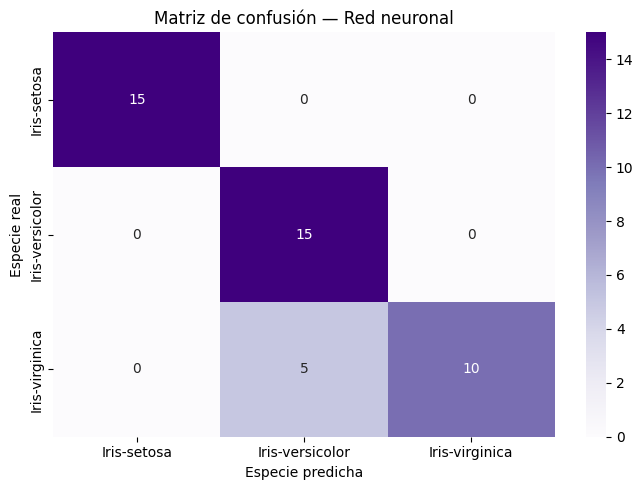

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# Preparar los datos de prueba sin volver a ajustar el escalador
X_test_scaled = escalador_rn.transform(X_test)
y_test_num = codificador_rn.transform(y_test)
y_test_cat = to_categorical(y_test_num, num_classes=n_clases)

# Evaluación
loss_rn, accuracy_rn = modelo_rn.evaluate(
    X_test_scaled,
    y_test_cat,
    verbose=0
)

print(f"Pérdida en prueba: {loss_rn:.4f}")
print(f"Accuracy en prueba: {accuracy_rn:.3f}")

# Probabilidades y clases predichas
y_prob_rn = modelo_rn.predict(X_test_scaled, verbose=0)
y_pred_rn = np.argmax(y_prob_rn, axis=1)

clases_rn = codificador_rn.classes_
indices_rn = np.arange(n_clases)

print("\nReporte de clasificación:")
print(classification_report(
    y_test_num,
    y_pred_rn,
    labels=indices_rn,
    target_names=[str(clase) for clase in clases_rn],
    zero_division=0
))

# Matriz de confusión
matriz_rn = confusion_matrix(
    y_test_num,
    y_pred_rn,
    labels=indices_rn
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_rn,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=clases_rn,
    yticklabels=clases_rn
)

plt.title("Matriz de confusión — Red neuronal")
plt.xlabel("Especie predicha")
plt.ylabel("Especie real")
plt.tight_layout()
plt.show()

[GRÁFICA 9]. Matriz de confusión de la red neuronal.

### Curva ROC
Las curvas ROC muestran qué tan bien distingue la red neuronal a cada especie frente a las otras dos al variar el umbral de clasificación. Iris setosa obtuvo un AUC de 1.0, mientras que Iris versicolor alcanzó 0.96 e Iris virginica 0.97. Las tres curvas se encuentran cerca de la esquina superior izquierda y también están por encima de la línea del azar, lo que indica una buena capacidad para diferenciar las especies.

Estos resultados no significan que todas las predicciones sean correctas, como se mostró en la matriz de confusión anteriormente.

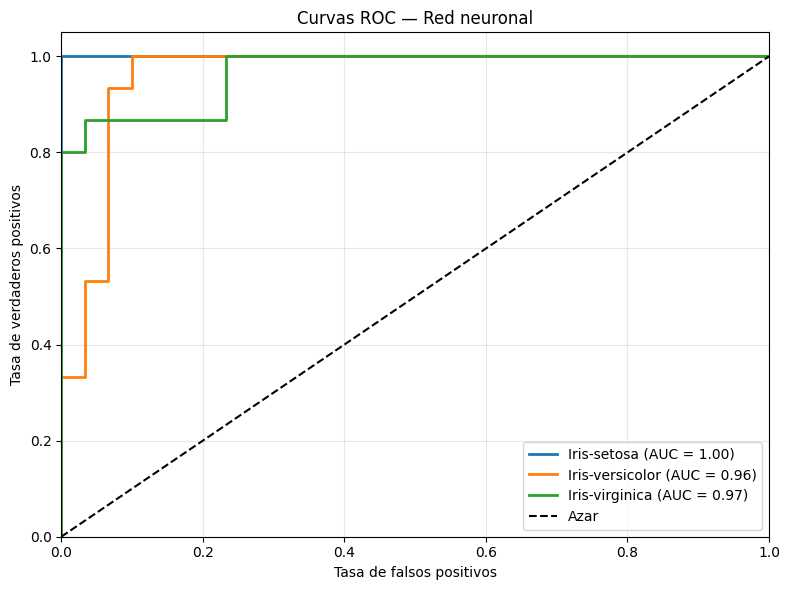

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probabilidades del modelo entrenado
y_prob_rn = modelo_rn.predict(X_test_scaled, verbose=0)

plt.figure(figsize=(8, 6))

for i, especie in enumerate(codificador_rn.classes_):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_prob_rn[:, i])
    auc_rn = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{especie} (AUC = {auc_rn:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Azar")

plt.title("Curvas ROC — Red neuronal")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[GRÁFICA 10]. Curva ROC de la red neuronal.

### Evolución de la exactitud y pérdida del modelo durante entrenamiento y prueba

La gráfica de exactitud muestra que la red neuronal mejora durante el entrenamiento, pasando de 56% a 99%. La exactitud de validación también aumenta y termina cerca del 90%.

En la gráfica de pérdida, ambas curvas disminuyen de forma continua. La pérdida de entrenamiento termina cerca de 0.15 y la de validación alrededor de 0.20, lo que indica una mejora en las probabilidades asignadas a las especies. Aunque el modelo tiene mejores resultados en entrenamiento, no se observa un aumento sostenido de la pérdida de validación que indique un sobreajuste.

El entrenamiento completó las 300 épocas sin activar Early Stopping, ya que la pérdida de validación siguió mejorando.

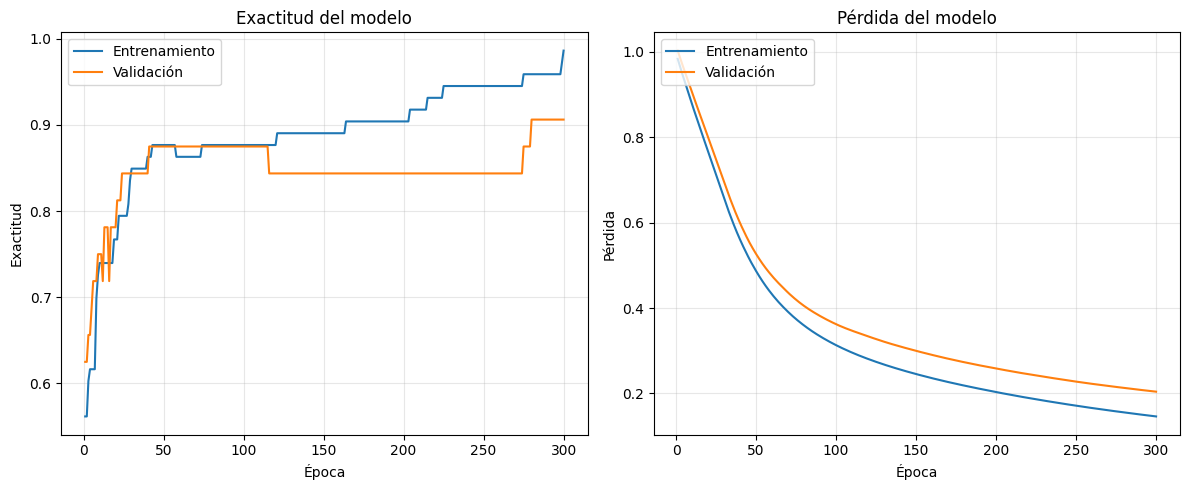

Se completaron 300 épocas sin activar EarlyStopping.


In [22]:
import matplotlib.pyplot as plt

n_epocas = len(history.history["loss"])
epocas = range(1, n_epocas + 1)

# 0 significa que EarlyStopping no detuvo el entrenamiento
stopped_epoch = getattr(early_stopping, "stopped_epoch", 0)
se_detuvo = stopped_epoch is not None and stopped_epoch > 0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de exactitud
axes[0].plot(
    epocas, history.history["accuracy"], label="Entrenamiento"
)
axes[0].plot(
    epocas, history.history["val_accuracy"], label="Validación"
)
axes[0].set_title("Exactitud del modelo")
axes[0].set_ylabel("Exactitud")

# Gráfica de pérdida
axes[1].plot(
    epocas, history.history["loss"], label="Entrenamiento"
)
axes[1].plot(
    epocas, history.history["val_loss"], label="Validación"
)
axes[1].set_title("Pérdida del modelo")
axes[1].set_ylabel("Pérdida")

# Mostrar la línea solamente si EarlyStopping se activó
for ax in axes:
    if se_detuvo:
        ax.axvline(
            x=stopped_epoch + 1,
            color="red",
            linestyle="--",
            label="Detención por EarlyStopping"
        )

    ax.set_xlabel("Época")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

if se_detuvo:
    print(f"EarlyStopping detuvo el entrenamiento en la época {stopped_epoch + 1}.")
else:
    print(f"Se completaron {n_epocas} épocas sin activar EarlyStopping.")

[GRÁFICAS 11 y 12]. Gráficas de la exactitud y pérdida del modelo.

## Evaluación y comparación de modelos
Boosting y SVM obtuvieron el mejor desempeño, con una exactitud de 95.6 %. Ambos identificaron correctamente todas las plantas Iris setosa e Iris versicolor, y confundieron dos plantas Iris virginica con Iris versicolor. Random Forest presentó tres errores y la red neuronal tuvo cinco errores. Por tanto, la principal dificultad de ltodos los modelos evaluados fue distinguir entre estas últimas dos especies.

La diferencia entre Boosting o SVM y Random Forest fue marginal, pues equivale a una planta adicional clasificada correctamente, o 2.2 puntos porcentuales de exactitud. Frente a la red neuronal, la diferencia fue mayor, fueron tres aciertos adicionales y 6.7 puntos porcentuales.

Una mayor complejidad no garantizó un mejor resultado. La red neuronal requirió configurar sus capas, el optimizador y el entrenamiento durante 300 épocas, pero obtuvo la menor exactitud con la configuración utilizada. Además, aprendió con 73 plantas y reservó 32 para validación, mientras que los otros modelos utilizaron las 105 plantas de entrenamiento.

En este caso, Boosting y SVM ofrecieron los mejores resultados en prueba, aunque su ventaja sobre Random Forest fue pequeña.

In [23]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Modelos ya entrenados: ajusta sus nombres si es necesario
modelos = {
    "Random Forest": modelo_rf,
    "Boosting": modelo_boosting,
    "SVM": modelo_svm
}

resultados = []

def agregar_resultados(nombre, reales, predicciones):
    resultados.append({
        "Modelo": nombre,
        "Exactitud (%)": accuracy_score(reales, predicciones) * 100,
        "Precisión macro": precision_score(
            reales, predicciones, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            reales, predicciones, average="macro", zero_division=0
        ),
        "F1-score macro": f1_score(
            reales, predicciones, average="macro", zero_division=0
        ),
        "Aciertos": int(np.sum(np.asarray(reales) == predicciones)),
        "Errores": int(np.sum(np.asarray(reales) != predicciones))
    })

# Evaluar Random Forest, Boosting y SVM
for nombre, modelo in modelos.items():
    predicciones = modelo.predict(X_test)
    agregar_resultados(nombre, y_test, predicciones)

# Evaluar la red neuronal
X_test_scaled = escalador_rn.transform(X_test)
probabilidades_rn = modelo_rn.predict(X_test_scaled, verbose=0)

# Convertir las salidas a las etiquetas originales
predicciones_rn = codificador_rn.inverse_transform(
    np.argmax(probabilidades_rn, axis=1)
)

agregar_resultados("Red neuronal", y_test, predicciones_rn)

# Mostrar una sola tabla sin índice
tabla_comparacion = pd.DataFrame(resultados)

display(
    tabla_comparacion.style
    .set_caption("[TABLA 3]. Comparación del desempeño de los modelos en el conjunto de prueba")
    .format({
        "Exactitud (%)": "{:.1f}",
        "Precisión macro": "{:.3f}",
        "Recall macro": "{:.3f}",
        "F1-score macro": "{:.3f}"
    })
    .hide(axis="index")
)

Modelo,Exactitud (%),Precisión macro,Recall macro,F1-score macro,Aciertos,Errores
Random Forest,93.3,0.944,0.933,0.933,42,3
Boosting,95.6,0.961,0.956,0.955,43,2
SVM,95.6,0.961,0.956,0.955,43,2
Red neuronal,88.9,0.917,0.889,0.886,40,5


## Análisis crítico y conclusiones
Los resultados muestran que una mayor complejidad no produjo una mejora clara en el desempeño. Boosting y SVM alcanzaron una exactitud de 95.6%, pero su ventaja sobre Random Forest, con 93.3%, fue de una sola planta correctamente clasificada. La red neuronal obtuvo 88.9 %, a pesar de requerir un entrenamiento de 300 épocas. Esto indica que la utilidad de cada modelo depende de los datos y de su configuración.

En cuanto al sobreajuste, la red neuronal alcanzó aproximadamente 99% de exactitud en entrenamiento y 90% en validación. Esta diferencia señala que aprendió mejor los datos utilizados para ajustar sus pesos. Sin embargo, la pérdida de validación continuó disminuyendo, por lo que no se muestra un sobreajuste claro.

La interpretabilidad también cambia entre los modelos. Random Forest permite analizar la importancia de las variables, aunque comprender todas las decisiones del conjunto de árboles es difícil. Boosting también puede ofrecer importancias, pero la combinación secuencial de árboles complica su explicación. SVM con núcleo RBF y la red neuronal son menos fáciles de interpretar, porque sus predicciones no se expresan mediante reglas sencillas sobre las medidas de las plantas.

Random Forest podría preferirse cuando interesa obtener buenas predicciones y conocer qué variables contribuyen más al modelo. Boosting puede ser útil cuando se busca mejorar el desempeño mediante ajustes cuidadosos. SVM es una opción adecuada para conjuntos pequeños con límites de separación no lineales, siempre que las variables se estandaricen. Las redes neuronales pueden resultar útiles para patrones más complejos y conjuntos mayores, aunque en este trabajo no superó a los otros modelos.

Finalmente, la comparación tiene limitaciones: solo se evaluaron 45 plantas y la red neuronal utilizó 73 para aprender, mientras que los otros modelos utilizaron 105. Los cuatro enfoques reconocieron bien Iris setosa, y su principal dificultad fue distinguir Iris versicolor de Iris virginica. La elección debe considerar el desempeño, la estabilidad de los resultados, la facilidad de interpretación y los recursos necesarios para entrenar cada modelo.

## Bibliografía
Fisher, R. (1936). Iris [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56C76.